# Phase 4 — 17-Patient Test Set Inference

Runs the same GT-loading / Dice convention as `analysis_abstract_17patients.ipynb` against the Phase 4 checkpoints (P4/P1/P2 + the seed-42 replica as a same-recipe reference).

**Touches the 17-patient test set** — explicit exception, same basis as debug test 2's variant comparison. Not for use during ongoing debugging without a deliberate decision to look.

**Prerequisite (run on BigRed first):** `slurm_files/infer_phase4_17pt.sh`, then scp `results/real_pd_predictions_{replica_seed42,p4,p1,p2}_17pt/` down into this repo's `results/`.

Section 1 = fresh 17-patient test Dice (what this notebook computes).
Section 2 = the 2 real-val patients' **validation** Dice, pulled directly from each run's `history.csv` — no inference needed for that part, it's already logged during training.

In [10]:
import os
import glob
import re
import csv

import numpy as np
import pandas as pd
import nibabel as nib
import SimpleITK as sitk
import matplotlib.pyplot as plt
from scipy.ndimage import zoom

In [11]:
# ── Paths ──────────────────────────────────────────────────────────────────
BASE = "/Users/anshikabajpai/Desktop/github/RegGAN_domain_adaptation_v2"
RES  = f"{BASE}/results"
RUNS = f"{BASE}/segmentation_runs"

GT_DIR_D1  = "/Users/anshikabajpai/Desktop/AImed-lab/SEGMENTATIONS/PD-segmentations-final"
GT_DIR_NEW = "/Users/anshikabajpai/Downloads/final-segmentations"   # NOT "segmentations" -- landmine

# label -> (prediction dir for 17pt inference, run dir holding history.csv for val Dice)
RUNS_INFO = {
    "replica_seed42": (f"{RES}/real_pd_predictions_replica_seed42_17pt", f"{RUNS}/run_v7_replica_seed42"),
    "P4 (stride+aug)": (f"{RES}/real_pd_predictions_p4_17pt",            f"{RUNS}/run_v7_p4"),
    "P1 (sampler cap)": (f"{RES}/real_pd_predictions_p1_17pt",           f"{RUNS}/run_v7_p1"),
    "P2 (negatives)":  (f"{RES}/real_pd_predictions_p2_17pt",            f"{RUNS}/run_v7_p2"),
}

D1_PATIENTS = [
    "AC0D5A4D78B628", "AC0D7BF72F7712", "AC0D3459553205", "AC14D3737C0482",
    "AC19E7C19827FF", "AC149BC218E75C", "AC111633B463BB", "AC13300201B926",
    "AC12026D14291F", "AC13637DA25399",
]
NEW_PATIENTS = [
    "AC000550763509", "AC005135D3495B", "AC04433E37DB66", "AC056ADCE8BE28",
    "AC07607B9E5295", "AC0D1A9818A6FC", "AC0F11041F5180",
]
ALL_PATIENTS = D1_PATIENTS + NEW_PATIENTS

# the 2 real-PD VALIDATION patients (never in the 17pt test set)
VAL_PATIENTS = ["AC0CE315D5758B", "AC0CEE9C24F2B7"]

print(f"Test set: {len(ALL_PATIENTS)} patients (D1={len(D1_PATIENTS)}, new={len(NEW_PATIENTS)})")
print(f"Val set : {len(VAL_PATIENTS)} patients (never overlaps the test set)")

Test set: 17 patients (D1=10, new=7)
Val set : 2 patients (never overlaps the test set)


## Helpers — same convention as `analysis_abstract_17patients.ipynb`

In [12]:
def get_pid(fname):
    m = re.match(r"(AC[A-F0-9]+)", os.path.basename(fname), re.IGNORECASE)
    return m.group(1) if m else None

def patients_in_dir(directory):
    files = glob.glob(os.path.join(directory, "*.nii.gz"))
    return {get_pid(f): f for f in files if get_pid(f)}

def load_vol(path):
    return np.asarray(nib.load(path).get_fdata())

def load_nrrd_binary(path):
    """Verbatim convention from analysis_abstract_17patients.ipynb / compare_stack_variants.py."""
    img = sitk.ReadImage(path)
    arr = sitk.GetArrayFromImage(img)
    if arr.ndim == 4:
        arr = (arr.max(axis=0) > 0).astype(np.uint8)
        out = sitk.GetImageFromArray(arr)
        try:
            comp = sitk.VectorIndexSelectionCast(img, 0)
            out.CopyInformation(comp)
        except Exception:
            out.SetSpacing(img.GetSpacing()[:3]); out.SetOrigin(img.GetOrigin()[:3])
            out.SetDirection(img.GetDirection()[:9])
    else:
        arr = (arr > 0).astype(np.uint8)
        out = sitk.GetImageFromArray(arr)
        out.CopyInformation(img)
    try:
        out = sitk.DICOMOrient(out, "RAS")
    except Exception:
        pass
    sp  = out.GetSpacing()
    arr = sitk.GetArrayFromImage(out).astype(np.float32).transpose(2, 1, 0)
    fa  = float(sp[1]) / min(sp[1], sp[2])
    fs  = float(sp[2]) / min(sp[1], sp[2])
    if abs(fa - 1.0) > 0.02 or abs(fs - 1.0) > 0.02:
        arr = zoom(arr, (1.0, fa, fs), order=0)
    _, n_A, n_S = arr.shape
    if n_A != 384 or n_S != 384:
        arr = zoom(arr, (1.0, 384 / n_A, 384 / n_S), order=0)
    return (arr > 0.5).astype(bool)

def merge_meniscus(pred):
    return (pred > 0).astype(bool)

def dice_score(pred_bin, gt_bin):
    if pred_bin.shape != gt_bin.shape:
        raise ValueError(f"shape mismatch: pred {pred_bin.shape} vs gt {gt_bin.shape} "
                         f"— refusing to silently resample, fix the source")
    inter = (pred_bin & gt_bin).sum()
    denom = pred_bin.sum() + gt_bin.sum()
    return float(2 * inter / denom) if denom > 0 else 1.0

## Section 1 — 17-patient test Dice (fresh inference, from `infer_phase4_17pt.sh`)

In [13]:
gt_masks = {}
for pid in ALL_PATIENTS:
    hits = (glob.glob(os.path.join(GT_DIR_D1,  f"{pid}*.seg.nrrd")) or
            glob.glob(os.path.join(GT_DIR_NEW, f"{pid}*.seg.nrrd")))
    if hits:
        gt_masks[pid] = hits[0]
    else:
        print(f"WARNING: No GT for {pid}")
print(f"GT masks found: {len(gt_masks)}/{len(ALL_PATIENTS)}")

preds_by_run = {}
for label, (pred_dir, _) in RUNS_INFO.items():
    d = patients_in_dir(pred_dir) if os.path.isdir(pred_dir) else {}
    preds_by_run[label] = d
    status = f"{len(d)}/{len(ALL_PATIENTS)}" if d else "NOT FOUND — pull results down / run 4.7-4.9 first"
    print(f"{label:<18}: {status}")

GT masks found: 17/17
replica_seed42    : 17/17
P4 (stride+aug)   : 17/17
P1 (sampler cap)  : 17/17
P2 (negatives)    : 17/17


In [14]:
rows = []
for pid in ALL_PATIENTS:
    if pid not in gt_masks:
        continue
    gt_bin = load_nrrd_binary(gt_masks[pid])
    row = {"patient": pid, "cohort": "D1" if pid in D1_PATIENTS else "new"}
    for label, preds in preds_by_run.items():
        if pid in preds:
            pred = load_vol(preds[pid])
            row[label] = dice_score(merge_meniscus(pred), gt_bin)
        else:
            row[label] = float("nan")
    rows.append(row)

df = pd.DataFrame(rows)
means = df[list(RUNS_INFO.keys())].mean()
print("MEAN 17pt Dice per run:")
print(means.round(4).to_string())
df

MEAN 17pt Dice per run:
replica_seed42      0.7780
P4 (stride+aug)     0.7856
P1 (sampler cap)    0.7489
P2 (negatives)      0.7795


,patient,cohort,replica_seed42,P4 (stride+aug),P1 (sampler cap),P2 (negatives)
0,AC0D5A4D78B628,D1,0.687259,0.721966,0.684675,0.652306
1,AC0D7BF72F7712,D1,0.761648,0.786028,0.689100,0.755789
2,AC0D3459553205,D1,0.717305,0.749608,0.693318,0.750764
3,AC14D3737C0482,D1,0.759853,0.756300,0.729213,0.736819
4,AC19E7C19827FF,D1,0.806665,0.795237,0.770425,0.765613
5,AC149BC218E75C,D1,0.799785,0.811031,0.773583,0.771700
6,AC111633B463BB,D1,0.835199,0.824600,0.796834,0.852780
7,AC13300201B926,D1,0.779674,0.779845,0.752060,0.758300
8,AC12026D14291F,D1,0.788027,0.783397,0.754194,0.791769
9,AC13637DA25399,D1,0.802916,0.812115,0.765497,0.804078


In [15]:
# Control check: replica_seed42 has never been run on the 17pt set before this
# notebook. It's the same recipe as v7_mixed but a different seed, so expect
# it CLOSE to (not necessarily equal to) v8_mixed's known 0.781 -- large
# deviation would be worth investigating before trusting the other columns.
if "replica_seed42" in means.index and not np.isnan(means["replica_seed42"]):
    print(f"replica_seed42 17pt mean: {means['replica_seed42']:.4f}  (reference: v8_mixed = 0.781)")

replica_seed42 17pt mean: 0.7780  (reference: v8_mixed = 0.781)


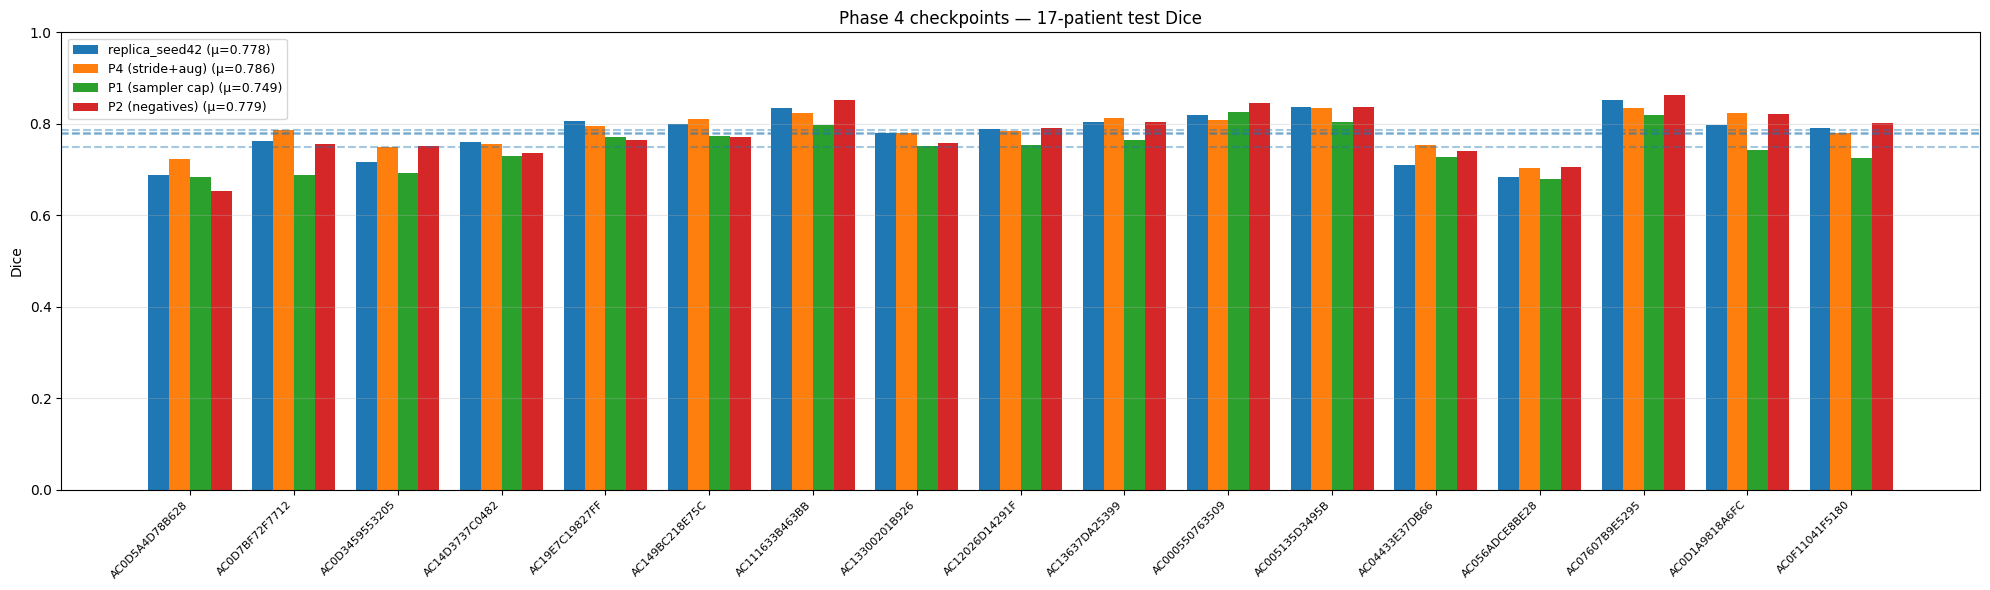

In [16]:
fig, ax = plt.subplots(figsize=(20, 6))
x = np.arange(len(df))
labels = [l for l in RUNS_INFO if df[l].notna().any()]
w = 0.8 / max(len(labels), 1)
for i, label in enumerate(labels):
    ax.bar(x + i * w, df[label], w, label=f"{label} (μ={means[label]:.3f})")
    ax.axhline(means[label], linestyle="--", alpha=0.4)
ax.set_xticks(x + w * (len(labels) - 1) / 2)
ax.set_xticklabels(df["patient"], rotation=45, ha="right", fontsize=8)
ax.set_ylabel("Dice"); ax.set_ylim(0, 1.0)
ax.set_title("Phase 4 checkpoints — 17-patient test Dice")
ax.legend(fontsize=9); ax.grid(axis="y", alpha=0.3)
plt.tight_layout(); plt.show()

## Section 2 — Validation Dice (2 real-val patients, from `history.csv`)

No inference needed here — every Phase 4 run already logs per-patient validation Dice at its own best epoch (the `dice_va_<pid>` columns in `history.csv`, same format across the replica, P4, P1, P2). This is the number `ckpt_best.pth` was actually selected on.

In [17]:
def best_epoch_val_dice(history_path):
    """Returns (best_epoch, dice_real_va, {pid: dice_va_pid}, dice_real_tr, gap) at
    the epoch dice_real_va is maximized -- same criterion ckpt_best.pth uses."""
    if not os.path.exists(history_path):
        return None
    rows = list(csv.DictReader(open(history_path)))
    best = max(rows, key=lambda r: float(r["dice_real_va"]))
    per_pid = {p: float(best.get(f"dice_va_{p}", "nan")) for p in VAL_PATIENTS}
    return {
        "best_epoch": int(best["epoch"]),
        "dice_real_va": float(best["dice_real_va"]),
        "dice_real_tr": float(best["dice_real_tr"]),
        "gap": float(best["gap"]),
        **{f"val_{p}": v for p, v in per_pid.items()},
    }

val_rows = []
for label, (_, run_dir) in RUNS_INFO.items():
    info = best_epoch_val_dice(os.path.join(run_dir, "history.csv"))
    if info is None:
        print(f"{label:<18}: history.csv not found under {run_dir}")
        continue
    val_rows.append({"run": label, **info})

val_df = pd.DataFrame(val_rows)
val_df

P2 (negatives)    : history.csv not found under /Users/anshikabajpai/Desktop/github/RegGAN_domain_adaptation_v2/segmentation_runs/run_v7_p2


,run,best_epoch,dice_real_va,dice_real_tr,gap,val_AC0CE315D5758B,val_AC0CEE9C24F2B7
0,replica_seed42,10,0.78091,0.92470,0.14379,0.75450,0.75063
1,P4 (stride+aug),15,0.78990,0.93629,0.14639,0.77216,0.75959
2,P1 (sampler cap),19,0.74295,0.84296,0.10001,0.71737,0.71230


In [18]:
# Test Dice (Section 1) vs Validation Dice (Section 2), side by side.
# Noise floor from the seed-42/seed-7 comparison: per-patient max |delta| = 0.0226.
# Any difference smaller than that between runs is not distinguishable from chance.
NOISE_FLOOR = 0.0226

combined = val_df[["run", "dice_real_va", "gap", "best_epoch"]].copy()
combined["test_17pt_mean"] = combined["run"].map(means.to_dict())
combined["test_minus_val"] = combined["test_17pt_mean"] - combined["dice_real_va"]
print(f"Noise floor (seed42 vs seed7, per-patient max |delta|): {NOISE_FLOOR}")
print("Differences vs the replica smaller than this are not distinguishable from chance.\n")
combined

Noise floor (seed42 vs seed7, per-patient max |delta|): 0.0226
Differences vs the replica smaller than this are not distinguishable from chance.



,run,dice_real_va,gap,best_epoch,test_17pt_mean,test_minus_val
0,replica_seed42,0.78091,0.14379,10,0.778037,-0.002873
1,P4 (stride+aug),0.78990,0.14639,15,0.785578,-0.004322
2,P1 (sampler cap),0.74295,0.10001,19,0.748884,0.005934
